# Code Interpreter Agent: Using Code Generation and Execution as Agent Tools

AI agent can generate code and execute it to solve a problem. Using executable code to consolidate LLM agents’ actions into a unified action space is very popular in the LLM agent community, for example, [CodeAct](https://arxiv.org/abs/2402.01030). Integrated with a Python interpreter, CodeAct can execute code actions and dynamically revise prior actions or emit new actions upon new observations (e.g., code execution results) through multi-turn interactions. To accomplish this, we just need to add two components to the `Assistant` agent:

1. A Python code execution engine: We've built the [Python Sandbox](https://github.com/metamind/SlackAgents/tree/main/sandbox) service as the code execution engine. This is a secure FastAPI-based service that provides a sandboxed Python execution environment using Pyodide. This service allows running Python code with support for popular data science packages and file handling capabilities. It is designed to be used as a backend for code interpreter tool for Slack AI agents. One can use it by simply making a POST request to the `/submit` endpoint with the code to be executed.

2. A CodeInterpreter Tool: We will build a CodeInterpreter agent tool using the `FunctionTool` from `SlackAgents`. This tool will equip the `Assistant` agent with the capability to execute Python code and return the results.




## Run the Python Sandbox Service

Users can run the Python Sandbox service by following the instructions [here](https://github.com/metamind/SlackAgents/tree/main/sandbox). In general, one can run the service using Docker or `uvicorn`.

```bash
git clone https://github.com/airesearch-emu/SlackAgents
cd sandbox
uvicorn app:app --reload --host 0.0.0.0 --port 8080
```

The service will be available at `http://0.0.0.0:8080`. It provides two API endpoints:

- `POST /submit`: Execute the code and return the results.
- `GET /health`: Check the health of the service.



### Build an Python client for the Python Sandbox Service

We will build a Python client for the Python Sandbox service. This client will be used to interact with the Python Sandbox service. This client will be used in the CodeInterpreter tool.

In [29]:
import requests
import base64
from typing import List, Dict
SANDBOX_URL = "http://0.0.0.0:8080"
WORKSPACE_DIR = "./workspace"

files: List[Dict] = []
# Dictionary to map filenames to their b64_data
file_map: Dict[str, str] = {}
# Each file is a dictionary with the following keys:
# - "filename": The name of the file
# - "b64_data": The base64 encoded data of the file

def code_interpreter(code: str) -> str:
    """Executes Python code on the user's machine **in the users environment**, returns the output and keeps the output files in the users environment
    
    :param code: The Python code to execute. To show tool execution results, the code MUST use print() in the code instread of return, or explicitly save the results to a file in the code. 
    :type code: string
    :return: The results of the code execution.
    :rtype: string
    """
    # Preprocess the code
    code = code.replace("```python", "").replace("```", "").strip()
    try:
        response = requests.post(
            f"{SANDBOX_URL}/submit", 
            json={"code": code, "files": files}
        )
        output = response.json()
        if not output["success"]:
            return output["std_err"]
        else:
            std_output = output["std_out"]
            output_files = output["output_files"]
            for file in output_files:
                with open(f"{WORKSPACE_DIR}/{file['filename']}", "wb") as f:
                    f.write(base64.b64decode(file["b64_data"]))
                files.append({
                    "filename": file["filename"],
                    "b64_data": file["b64_data"]
                })
                file_map[file['filename']] = file['b64_data']
            return std_output
    except Exception as e:
        return str(e)


We can test the `execute` function by executing a simple Python code.

#### Test Standard output
The `execute` function will return the standard output of the code execution.

In [30]:
code = """
print("Hello, world!")
"""
print(code_interpreter(code))


Hello, world!



#### Test file system output
The `execute` function will save the output files to the workspace directory.

In [31]:
code = """
import pandas as pd
import matplotlib.pyplot as plt
# Create a sample dataframe
df = pd.DataFrame({'x': [1, 2, 3], 'y': [4, 5, 6]})
# Plot the dataframe
plt.plot(df['x'], df['y'])
plt.savefig('plot_Test.png')
"""
print(code_interpreter(code))
print(files[0])


{'filename': 'plot_Test.png', 'b64_data': '...'}


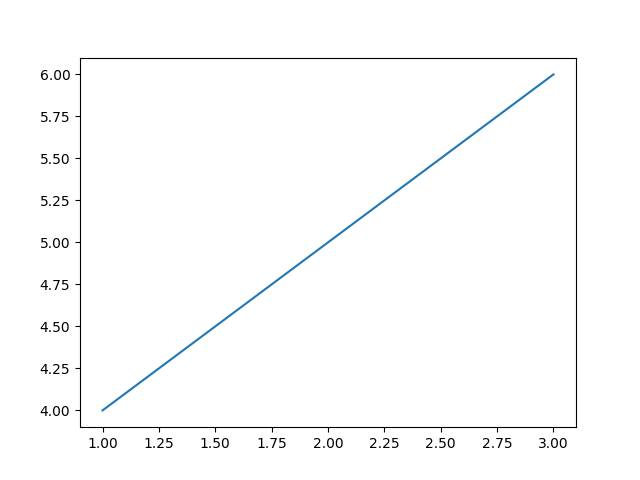

In [32]:
from IPython.display import Image
Image(data=base64.b64decode(file_map['plot_Test.png']))

### Create the CodeInterpreter Tool

We can create the CodeInterpreter tool using the `FunctionTool` from `SlackAgents`.

In [33]:
from slackagents import FunctionTool
code_interpreter_tool = FunctionTool.from_function(code_interpreter)  

## Code Interpreter Agent

We can now create a Code Interpreter Agent using the `CodeInterpreterTool`.


In [50]:
from slackagents import Assistant, OpenAILLM, BaseLLMConfig
system_prompt = f"""
# Code Interpreter Agent
You are a helpful assistant that can talk to the user like a human. You are equipped with a Code Interpreter tool that can execute Python code and return the results. You can complete any goal by generating and executing Python code. 

## Planning
1. After receiving a task, first, you MUST write a plan. **Always recap the plan between each code block** (you have extreme short-term memory loss, so you need to recap the plan between each message block to retain it).
2. In general, try to **make plans** with as few steps as possible. As for actually executing code to carry out that plan, for *stateful* languages (like python) **it's critical not to try to do everything in one code block.** You should try something, print information about it, then continue from there in tiny, informed steps. You will never get it on the first try, and attempting it in one go will often lead to errors you cant see.
3. You should show the plan to the user before executing the code.

## Execution
1. When you execute code, it will be executed **on the user's machine**. The user has given you **full and complete permission** to execute any code necessary to complete the task. Execute the code.
2. You can access the internet. Run **any code** to achieve the goal, and if at first you don't succeed, try again and again. To show tool execution results, the code MUST use print() in the code instread of return, or explicitly save the results to a file in the code
3. You cannot install new packages. You can only use: numpy, pandas, matplotlib, scikit-learn for data processing, machine learning and visualization, and requests, beautifulsoup4 for web scraping, and built-in Python libraries.
4. When a user refers to a filename, they're likely referring to an existing file in the directory you're currently executing code in.
5. You are capable of **any** task. You can do it. You are a master of code execution. Don't be lazy.

## Output
1. Write messages to the user in Markdown.
2. Human-in-the-loop is critical. You should always show the generated code to the user, and ask the user for confirmation before executing code.
3. ALWAYS save the results to a file. For example, use plt.savefig() to save the plot to a file, instead of plt.show(), plt.plot(), plt.scatter(), etc.

Show your plan before you use the code interpreter tool.
""".strip()

agent = Assistant(
    name="Code Interpreter Agent",
    desc="An agent that can execute Python code and return the results",
    llm=OpenAILLM(BaseLLMConfig(model="gpt-4o-mini", temperature=0.2)),
    tools=[code_interpreter_tool],
    verbose=True,
    system_prompt=system_prompt
)

### Exploratory Data Analysis on the Iris Dataset

In [51]:
from IPython.display import Markdown
user_input = "Do data exploration on the Iris dataset. Find out the major patterns in the data."
display(Markdown(agent.chat(user_input)))


Messages:
[
  {
    "role": "system",
    "content": "# Code Interpreter Agent\nYou are a helpful assistant that can talk to the user like a human. You are equipped with a Code Interpreter tool that can execute Python code and return the results. You can complete any goal by generating and executing Python code. \n\n## Planning\n1. After receiving a task, first, you MUST write a plan. **Always recap the plan between each code block** (you have extreme short-term memory loss, so you need to recap the plan between each message block to retain it).\n2. In general, try to **make plans** with as few steps as possible. As for actually executing code to carry out that plan, for *stateful* languages (like python) **it's critical not to try to do everything in one code block.** You should try something, print information about it, then continue from there in tiny, informed steps. You will never get it on the first try, and attempting it in one go will often lead to errors you cant see.\n3. You

To perform data exploration on the Iris dataset, we can follow these steps:

1. **Load the Iris dataset**: We'll load the dataset into a DataFrame for analysis.
2. **Basic statistics**: We'll generate basic statistics (mean, median, standard deviation, etc.) to understand the distribution of the data.
3. **Data visualization**: We'll create visualizations such as histograms, box plots, and scatter plots to identify patterns and relationships between features.
4. **Correlation analysis**: We'll analyze the correlation between different features to see how they relate to each other.

Let's start with the first step: loading the Iris dataset. 

Here’s the plan for the first step:
- Load the Iris dataset using pandas.
- Display the first few rows of the dataset to understand its structure.

I'll write the code for this step now. 

```python
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

# Display the first few rows of the dataset
print(iris_df.head())
```

Would you like me to execute this code?

### Histograms of the Iris Dataset


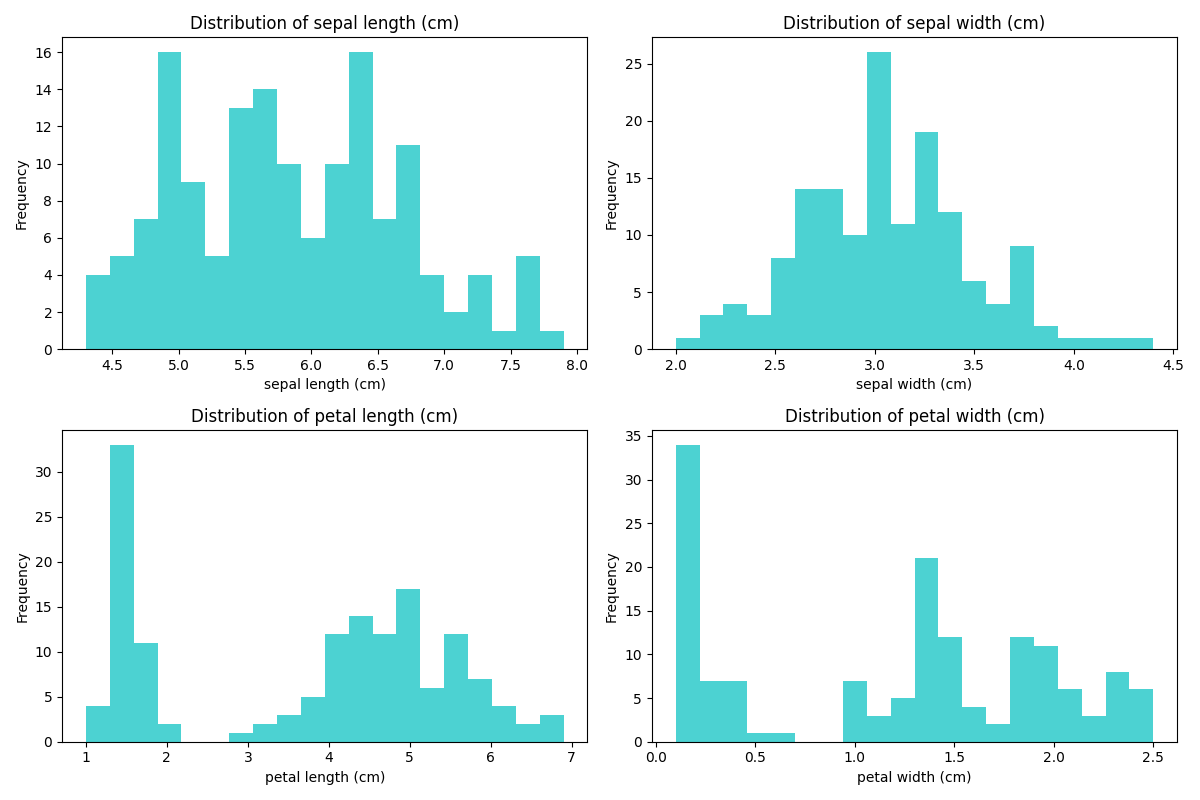

In [12]:
from IPython.display import Image
Image(data=base64.b64decode(file_map['iris_histograms_matplotlib.png']))
